# HW 1

In [33]:
import pandas as pd
import numpy as np

# print samples from the TweetEval Dataset
def print_samples(df, labels, n=5, random_state=15179996):
    from IPython.display import display

    sample_df = df.sample(n, random_state=random_state).copy()
    sample_df['Label'] = sample_df['label'].apply(lambda x: labels[x])
    sample_df['Tweet Text'] = sample_df['text'].str.replace('\n', ' ')

    display_df = sample_df[['Label', 'Tweet Text']]
    display(display_df)

# print the TweetEval Data Distribution
def print_distribution(train_df, test_df, labels):
    print(f"\nData Split")
    print(f"Training set: {len(train_df)}")
    print(f"Testing set:  {len(test_df)}")

    print("\nClass Distribution (Counts)")
    train_counts = train_df['label'].map(labels).value_counts()
    test_counts = test_df['label'].map(labels).value_counts()

    dist_df = pd.DataFrame({
        'Train Count': train_counts,
        'Test Count': test_counts,
        'Train %': (train_counts / len(train_df) * 100).round(2)
    })
    print(dist_df)

# Calculate the ECE from predictions and confidence
def calculate_ece(y_true, y_preds, confidences, n_bins=10):
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0
    total_samples = len(y_true)
    accuracies = (y_preds == y_true)
    for i in range(n_bins):
        if i == 0:
            bin_mask = (confidences >= bin_boundaries[i]) & (confidences <= bin_boundaries[i+1])
        else:
            bin_mask = (confidences > bin_boundaries[i]) & (confidences <= bin_boundaries[i+1])

        bin_size = np.sum(bin_mask)
        if bin_size > 0:
            bin_acc = np.mean(accuracies[bin_mask])
            bin_conf = np.mean(confidences[bin_mask])
            ece += (bin_size / total_samples) * np.abs(bin_acc - bin_conf)
    return ece

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# print the loss plot from training history
def loss_plot(log_history, model_name):
    train_data = [e for e in log_history if 'loss' in e]
    eval_loss_data = [e for e in log_history if 'eval_loss' in e]
    eval_f1_data = [e for e in log_history if 'eval_f1' in e]

    df_train = pd.DataFrame(train_data)
    df_eval_loss = pd.DataFrame(eval_loss_data)
    df_eval_f1 = pd.DataFrame(eval_f1_data)

    fig, ax1 = plt.subplots(figsize=(12, 6))
    sns.set_theme(style="whitegrid")

    # Plot losses on primary y-axis
    if not df_train.empty:
        ax1.plot(df_train['epoch'], df_train['loss'], 'o-', label='Train Loss', color='#1f77b4')
    if not df_eval_loss.empty:
        ax1.plot(df_eval_loss['epoch'], df_eval_loss['eval_loss'], 's-', label='Validation Loss', color='#ff7f0e')

    ax1.set_xlabel("Epoch", fontsize=12)
    ax1.set_ylabel("Loss", fontsize=12)
    ax1.grid(True, linestyle='--', alpha=0.7)

    # Plot Macro F1 on secondary y-axis
    if not df_eval_f1.empty:
        ax2 = ax1.twinx()
        ax2.plot(df_eval_f1['epoch'], df_eval_f1['eval_f1'], 'd-', label='Validation Macro F1', color='#2ca02c')
        ax2.set_ylabel("Macro F1", fontsize=12)
        ax2.grid(False)

        lines_1, labels_1 = ax1.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()
        ax1.legend(lines_1 + lines_2, labels_1 + labels_2, frameon=True, facecolor='white', loc='center right')
    else:
        ax1.legend(frameon=True, facecolor='white')

    plt.title(f"Training Metrics: {model_name}", fontsize=14, pad=15)
    plt.tight_layout()
    plt.show()

# show tokenization of a particular text
def show_tokenization(text):
    tokenizer_bert = DistilBERT_zero_shot_pipeline.tokenizer
    tokenizer_rob = DistilRoBERTa_zero_shot_pipeline.tokenizer

    tokens_bert = tokenizer_bert.tokenize(text)
    tokens_rob = tokenizer_rob.tokenize(text)

    return [
        {"Tokenizer": "WordPiece", "Model": "DistilBERT", "Tokens": tokens_bert},
        {"Tokenizer": "BPE", "Model": "DistilRoBERTa", "Tokens": tokens_rob}
    ]

In [2]:
import random
import re
import string

# Randomly introduce typos into a given text
def introduce_typos(text, prob=0.1):
    words = text.split()
    new_words = []

    for word in words:
        if len(word) > 3 and random.random() < prob:
            typo_type = random.choice(['swap', 'delete', 'insert'])
            idx = random.randint(0, len(word) - 2)

            if typo_type == 'swap':
                word_list = list(word)
                word_list[idx], word_list[idx+1] = word_list[idx+1], word_list[idx]
                word = "".join(word_list)
            elif typo_type == 'delete':
                idx = random.randint(0, len(word) - 1)
                word = word[:idx] + word[idx+1:]
            elif typo_type == 'insert':
                idx = random.randint(0, len(word))
                char = random.choice(string.ascii_lowercase)
                word = word[:idx] + char + word[idx:]
        new_words.append(word)

    return " ".join(new_words)

# hashtag splitting logic
def split_hashtags(text, prob=0.5):
    def repl(match):
        if random.random() < prob:
            hashtag = match.group(1)
            # Split CamelCase
            splitted = re.sub('([a-z0-9])([A-Z])', r'\1 \2', hashtag)
            return splitted
        return match.group(0)

    # Find hashtags followed by alphanumeric characters
    return re.sub(r'#(\w+)', repl, text)

# remove emojis from text
def remove_emojis(text):

    # Simple regex for emojis (covers most common ranges)
    emoji_pattern = re.compile(
        "["
        "\U0001f600-\U0001f64f"  # emoticons
        "\U0001f300-\U0001f5ff"  # symbols & pictographs
        "\U0001f680-\U0001f6ff"  # transport & map symbols
        "\U0001f1e0-\U0001f1ff"  # flags (iOS)
        "\U0001f900-\U0001f9ff"  # supplemental symbols and pictographs
        "\U00002702-\U000027b0"
        "\U000024c2-\U0001f251"
        "]+", flags=re.UNICODE
    )
    return emoji_pattern.sub(r'', text)

def apply_corruptions(text, corruptions):
    if 'typos' in corruptions:
        text = introduce_typos(text)
    if 'hashtag_split' in corruptions:
        text = split_hashtags(text)
    if 'emoji_removal' in corruptions:
        text = remove_emojis(text)
    return text

#Creates a dictionary of corrupted data.
def create_corruption_ablations(df):
    ablations = {
        "original": df.copy(),
        "corruption_typos": df.copy(),
        "corruption_hashtags": df.copy(),
        "corruption_emojis": df.copy(),
        "corruption_all": df.copy()
    }

    ablations["corruption_typos"]["text"] = ablations["corruption_typos"]["text"].apply(lambda x: introduce_typos(x))
    ablations["corruption_hashtags"]["text"] = ablations["corruption_hashtags"]["text"].apply(lambda x: split_hashtags(x))
    ablations["corruption_emojis"]["text"] = ablations["corruption_emojis"]["text"].apply(lambda x: remove_emojis(x))
    ablations["corruption_all"]["text"] = ablations["corruption_all"]["text"].apply(
        lambda x: apply_corruptions(x, ['typos', 'hashtag_split', 'emoji_removal'])
    )

    return ablations


In [3]:
import pandas as pd
import re

# filter the dataset by specified rules
def get_subset_by_feature(df, feature_type, present=True):
    if feature_type == 'mentions':
        pattern = r'@user|@\w+'
    elif feature_type == 'links':
        pattern = r'http\S+|http'
    elif feature_type == 'hashtags':
        pattern = r'#\w+'
    else:
        raise ValueError(f"Unknown feature type: {feature_type}")

    mask = df['text'].str.contains(pattern, case=False, regex=True, na=False)

    if present:
        return df[mask].copy()
    else:
        return df[~mask].copy()

# create sets of different corruptions
def create_shift_ablation_sets(df):
    shifts = {
        "full_test": df,
        "with_mentions": get_subset_by_feature(df, 'mentions', True),
        "no_mentions": get_subset_by_feature(df, 'mentions', False),
        "with_links": get_subset_by_feature(df, 'links', True),
        "no_links": get_subset_by_feature(df, 'links', False),
        "with_hashtags": get_subset_by_feature(df, 'hashtags', True),
        "no_hashtags": get_subset_by_feature(df, 'hashtags', False),
    }

    # Filter out empty sets just in case
    return {k: v for k, v in shifts.items() if len(v) > 0}

In [4]:
from datasets import load_dataset
import pandas as pd

def download_and_split_dataset():
    dataset = load_dataset("tweet_eval", "emotion")

    train_df = pd.DataFrame(dataset["train"])
    val_df = pd.DataFrame(dataset["validation"])
    test_df = pd.DataFrame(dataset["test"])

    return train_df, val_df, test_df

In [7]:
!pip install backoff

In [8]:
import time
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
from openai import OpenAI, AsyncOpenAI
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from tqdm import tqdm
import backoff
import asyncio

# Prompt Templates
PROMPT_1_MINIMAL = """Classify the following tweet into one of these emotions: anger, joy, optimism, sadness.
Tweet: {text}
Emotion:"""

PROMPT_2_STRUCTURED = """Task: Sentiment classification for tweets.
Labels:
- anger: The tweet expresses frustration, resentment, or rage.
- joy: The tweet expresses happiness, pleasure, or satisfaction.
- optimism: The tweet expresses hopefulness, confidence about the future, or positive anticipation.
- sadness: The tweet expresses sorrow, disappointment, or unhappiness.

Instructions:
1. Read the tweet provided below.
2. Select the most appropriate label from the list above.
3. Output ONLY the label name. Do not include any other text or explanation.

Tweet: {text}

Label:"""

LABELS = ["anger", "joy", "optimism", "sadness"]

class LLMEvaluator:
    def __init__(self, openai_api_key=None, base_url="https://openrouter.ai/api/v1", hf_model_name="Qwen/Qwen3-4B-Instruct-2507"):
        self.openai_api_key = openai_api_key
        self.openai_client = OpenAI(
            api_key=openai_api_key,
            base_url=base_url
        ) if openai_api_key else None
        self.openai_async_client = AsyncOpenAI(
            api_key=openai_api_key,
            base_url=base_url
        ) if openai_api_key else None
        self.hf_model_name = hf_model_name
        self.hf_model = None
        self.hf_tokenizer = None
        self.device = "cuda" if torch.cuda.is_available() else "cpu"

    def load_hf_model(self):
        print(f"Loading HF model: {self.hf_model_name} on {self.device}...")
        self.hf_tokenizer = AutoTokenizer.from_pretrained(self.hf_model_name)
        self.hf_tokenizer.padding_side = "left"
        if self.hf_tokenizer.pad_token is None:
            self.hf_tokenizer.pad_token = self.hf_tokenizer.eos_token

        self.hf_model = AutoModelForCausalLM.from_pretrained(
            self.hf_model_name,
            torch_dtype="auto",
            device_map="auto"
        )

    @backoff.on_exception(backoff.expo, Exception, max_tries=5)
    async def _call_openai_async(self, prompt, model="openai/gpt-4o-mini"):
        response = await self.openai_async_client.chat.completions.create(
            model=model,
            messages=[{"role": "user", "content": prompt}],
            temperature=0,
            max_tokens=10
        )
        return response.choices[0].message.content.strip().lower()

    async def _evaluate_batch_openai(self, prompts, model="openai/gpt-4o-mini"):
        semaphore = asyncio.Semaphore(20)
        async def sem_call(p):
            async with semaphore:
                return await self._call_openai_async(p, model=model)

        tasks = [sem_call(p) for p in prompts]
        return await asyncio.gather(*tasks)

    def call_hf_batch(self, prompts):
        """Process a batch of prompts using the HF model."""
        inputs = self.hf_tokenizer(prompts, return_tensors="pt", padding=True).to(self.device)
        input_length = inputs.input_ids.shape[1]

        with torch.no_grad():
            outputs = self.hf_model.generate(
                **inputs,
                max_new_tokens=10,
                temperature=0.1,
                do_sample=False,
                pad_token_id=self.hf_tokenizer.pad_token_id
            )

        responses = []
        for i in range(len(prompts)):
            decoded = self.hf_tokenizer.decode(outputs[i][input_length:], skip_special_tokens=True)
            responses.append(decoded.strip().lower())
        return responses

    def evaluate(self, df, model_type, prompt_template, batch_size=100):
        all_predictions = []
        batch_times = []

        try:
            loop = asyncio.get_event_loop()
        except RuntimeError:
            loop = asyncio.new_event_loop()
            asyncio.set_event_loop(loop)

        for i in tqdm(range(0, len(df), batch_size), desc=f"Evaluating {model_type} (Batch size {batch_size})"):
            batch_df = df.iloc[i : i + batch_size]
            prompts = [prompt_template.format(text=row['text']) for _, row in batch_df.iterrows()]

            start_time = time.time()
            if model_type == "openai":
                if loop.is_running():
                    try:
                        import nest_asyncio
                        nest_asyncio.apply()
                    except ImportError:
                        print("Warning: nest_asyncio not found. Async calls in Jupyter might fail. Run '!pip install nest_asyncio'")
                preds = loop.run_until_complete(self._evaluate_batch_openai(prompts))
            elif model_type == "hf":
                preds = self.call_hf_batch(prompts)
            else:
                raise ValueError(f"Unknown model_type: {model_type}")

            end_time = time.time()
            batch_duration_ms = (end_time - start_time) * 1000
            normalized_time = (batch_duration_ms / len(batch_df)) * 100
            batch_times.append(normalized_time)

            for pred in preds:
                pred_clean = "unknown"
                for label in LABELS:
                    if label in pred:
                        pred_clean = label
                        break
                all_predictions.append(pred_clean)

        y_true = [LABELS[i] for i in df['label']]
        acc = accuracy_score(y_true[:len(all_predictions)], all_predictions)
        f1 = f1_score(y_true[:len(all_predictions)], all_predictions, average='macro')

        avg_time_per_100 = sum(batch_times) / len(batch_times) if batch_times else 0

        return {
            "Accuracy": acc,
            "Macro-F1": f1,
            "Time_per_100": avg_time_per_100,
            "Predictions": all_predictions,
            "True_Labels": y_true
        }


In [45]:
import torch
import time
import numpy as np
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    DataCollatorWithPadding
)
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Evaluates a trained model on a given dataset
def evaluate(trainer, tokenizer, eval_df, name_label, candidate_labels):
    from datasets import Dataset
    eval_ds = Dataset.from_pandas(eval_df)

    def tokenize_func(examples):
        return tokenizer(examples["text"], truncation=True, padding=True)

    tokenized_eval = eval_ds.map(tokenize_func, batched=True)

    print(f"Evaluating {name_label} on provided dataset (size: {len(eval_df)})...")
    start_time = time.time()
    raw_predictions = trainer.predict(tokenized_eval)
    end_time = time.time()

    logits = raw_predictions.predictions
    probs = torch.nn.functional.softmax(torch.tensor(logits), dim=-1).numpy()
    preds = np.argmax(probs, axis=1)
    confidences = np.max(probs, axis=1)

    y_true = eval_df["label"].values
    time_per_100 = (((end_time - start_time) * 1000) / len(eval_df)) * 100 if len(eval_df) > 0 else 0
    acc = accuracy_score(y_true, preds)
    f1 = f1_score(y_true, preds, average='macro')
    ece = calculate_ece(y_true, preds, confidences)

    class_report_str = classification_report(y_true, preds, target_names=candidate_labels)
    class_report_dict = classification_report(y_true, preds, target_names=candidate_labels, output_dict=True)

    return {
        "Accuracy": acc,
        "Macro F1": f1,
        "ECE": ece,
        "Time/100": time_per_100,
        "Classification Report": class_report_str,
        "Classification Report Dict": class_report_dict
    }

# first train a model then evaluate
def train_and_evaluate(model_name, train_ds, val_ds, test_ds, test_df, name_label, candidate_labels, push_to_hub=False, hub_model_id=None):
    from transformers import set_seed
    set_seed(15179996)

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=4,
    )

    def tokenize_func(examples):
        return tokenizer(examples["text"], truncation=True, padding=True)

    tokenized_train = train_ds.map(tokenize_func, batched=True)
    tokenized_val = val_ds.map(tokenize_func, batched=True)

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        predictions = np.argmax(logits, axis=-1)
        acc = accuracy_score(labels, predictions)
        f1 = f1_score(labels, predictions, average='macro')
        return {"accuracy": acc, "f1": f1}

    training_args = TrainingArguments(
        output_dir=f"./results_{name_label}",
        num_train_epochs=20,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=100,
        learning_rate=2e-5,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_f1",
        greater_is_better=True,
        logging_steps=50,
        report_to="none",
        optim="adamw_torch",
        push_to_hub=push_to_hub,
        hub_model_id=hub_model_id,
        hub_strategy="every_save",
        seed=15179996,
        data_seed=15179996,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_val,
        data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
    )

    trainer.train()

    if push_to_hub:
        trainer.push_to_hub()

    results = evaluate(trainer, tokenizer, test_df, f"{name_label}_StandardTest", candidate_labels)
    results["Log History"] = trainer.state.log_history

    return results, trainer, tokenizer


In [11]:
from transformers import pipeline
import time
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report

def run_zero_shot(df, classifier, candidate_labels, hypothesis_template):

    texts = df["text"].tolist()

    predictions = classifier(
        texts,
        candidate_labels,
        hypothesis_template=hypothesis_template,
        batch_size=100
    )

    # Extract the top predicted label
    return [pred['labels'][0] for pred in predictions]

# create pipelines for inference

DistilBERT_zero_shot_pipeline = pipeline(
    "zero-shot-classification",
    model="distilbert-base-uncased",
    device=0
)

DistilRoBERTa_zero_shot_pipeline = pipeline(
    "zero-shot-classification",
    model="distilroberta-base",
    device=0
)


def run_benchmarked_inference(df, classifier, candidate_labels, label_id, hypothesis_template):
    texts = df["text"].tolist()

    start_time = time.time()

    raw_results = classifier(
        texts,
        candidate_labels,
        hypothesis_template=hypothesis_template,
        batch_size=100
    )

    end_time = time.time()

    # calculate time per 100 samples
    total_time_ms = (end_time - start_time) * 1000
    time_per_100 = (total_time_ms / len(texts)) * 100

    # Extract predicted labels and confidences
    preds_labels = [res['labels'][0] for res in raw_results]
    preds_ids = [label_id[label] for label in preds_labels]
    confidences = [res['scores'][0] for res in raw_results]

    # calculate metrics
    y_true = df["label"].values
    acc = accuracy_score(y_true, preds_ids)
    f1 = f1_score(y_true, preds_ids, average='macro')
    ece = calculate_ece(y_true, np.array(preds_ids), np.array(confidences))

    class_report_str = classification_report(y_true, preds_ids, target_names=candidate_labels)
    class_report_dict = classification_report(y_true, preds_ids, target_names=candidate_labels, output_dict=True)

    return {
        "Accuracy": acc,
        "Macro F1": f1,
        "ECE": ece,
        "Time/100": time_per_100,
        "Classification Report": class_report_str,
        "Classification Report Dict": class_report_dict
    }


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Failed to determine 'entailment' label id from the label2id mapping in the model config. Setting to -1. Define a descriptive label2id mapping in the model config to ensure correct outputs.


In [12]:
id_labels = {0: "anger", 1: "joy", 2: "optimism", 3: "sadness"}
labels_id = {"anger": 0, "joy": 1, "optimism": 2, "sadness": 3}
candidate_labels = list(id_labels.values())
hypothesis_template = "This tweet expresses {}."

In [13]:
train_df, val_df, test_df = download_and_split_dataset()
print(f"Training set: {len(train_df)}")
print(f"Testing set: {len(test_df)}")
print(f"Val set: {len(val_df)}")

README.md: 0.00B [00:00, ?B/s]

emotion/train-00000-of-00001.parquet:   0%|          | 0.00/233k [00:00<?, ?B/s]

emotion/test-00000-of-00001.parquet:   0%|          | 0.00/105k [00:00<?, ?B/s]

emotion/validation-00000-of-00001.parque(…):   0%|          | 0.00/28.6k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3257 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1421 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/374 [00:00<?, ? examples/s]

Training set: 3257
Testing set: 1421
Val set: 374


In [14]:
print_samples(train_df, id_labels)

,Label,Tweet Text
1096,sadness,This weather making me dread work tonight
787,sadness,We express our deep concern about the suspensi...
2476,anger,@user why is there no disabled access at ponte...
1250,anger,Niggas never changed...even as a kid and a 29 ...
913,sadness,im so gloomy today


In [15]:
print_distribution(train_df, test_df, id_labels)


Data Split
Training set: 3257
Testing set:  1421

Class Distribution (Counts)
          Train Count  Test Count  Train %
label                                     
anger            1400         558    42.98
sadness           855         382    26.25
joy               708         358    21.74
optimism          294         123     9.03


In [16]:
test_df["distilbert_pred"] = run_zero_shot(test_df, DistilBERT_zero_shot_pipeline, candidate_labels , hypothesis_template)

In [17]:
test_df["distilroberta_pred"] = run_zero_shot(test_df, DistilRoBERTa_zero_shot_pipeline, candidate_labels, hypothesis_template)

In [18]:
print(test_df[["text", "label", "distilbert_pred", "distilroberta_pred"]].head())

                                                text  label distilbert_pred  \
0  #Deppression is real. Partners w/ #depressed p...      3         sadness   
1  @user Interesting choice of words... Are you c...      0        optimism   
2  My visit to hospital for care triggered #traum...      3        optimism   
3  @user Welcome to #MPSVT! We are delighted to h...      1         sadness   
4                       What makes you feel #joyful?      1        optimism   

  distilroberta_pred  
0           optimism  
1              anger  
2           optimism  
3           optimism  
4              anger  


In [19]:
results = {}

In [20]:
results["DistilBERT (WordPiece)"] = run_benchmarked_inference(test_df, DistilBERT_zero_shot_pipeline, candidate_labels, labels_id, hypothesis_template)

In [21]:
results["DistilRoBERTa (BPE)"] = run_benchmarked_inference(test_df, DistilRoBERTa_zero_shot_pipeline, candidate_labels, labels_id, hypothesis_template)

In [22]:
import pandas as pd
key_metrics = ["Accuracy", "Macro F1", "ECE", "Time/100"]
pd.DataFrame({
    model_name: {metric: results[model_name][metric] for metric in key_metrics}
    for model_name in results.keys()
}).transpose()

,Accuracy,Macro F1,ECE,Time/100
DistilBERT (WordPiece),0.116115,0.103539,0.134611,310.820094
DistilRoBERTa (BPE),0.362421,0.223600,0.112255,298.274109


In [23]:
pd.DataFrame({
    model_name: {metric: results[model_name][metric] for metric in key_metrics}
    for model_name in results.keys()
}).transpose().to_markdown()

'|                        |   Accuracy |   Macro F1 |      ECE |   Time/100 |\n|:-----------------------|-----------:|-----------:|---------:|-----------:|\n| DistilBERT (WordPiece) |   0.116115 |   0.103539 | 0.134611 |    310.82  |\n| DistilRoBERTa (BPE)    |   0.362421 |   0.2236   | 0.112255 |    298.274 |'

In [24]:
import pandas as pd
report_df = pd.DataFrame(results["DistilBERT (WordPiece)"]["Classification Report Dict"]).transpose()
report_df

,precision,recall,f1-score,support
anger,0.650000,0.023297,0.044983,558.000000
joy,0.112150,0.033520,0.051613,358.000000
optimism,0.054811,0.365854,0.095339,123.000000
sadness,0.200846,0.248691,0.222222,382.000000
accuracy,0.116115,0.116115,0.116115,0.116115
macro avg,0.254452,0.167840,0.103539,1421.000000
weighted avg,0.342234,0.116115,0.098658,1421.000000


In [25]:
report_df.to_markdown()

'|              |   precision |    recall |   f1-score |     support |\n|:-------------|------------:|----------:|-----------:|------------:|\n| anger        |   0.65      | 0.0232975 |  0.0449827 |  558        |\n| joy          |   0.11215   | 0.0335196 |  0.0516129 |  358        |\n| optimism     |   0.0548112 | 0.365854  |  0.095339  |  123        |\n| sadness      |   0.200846  | 0.248691  |  0.222222  |  382        |\n| accuracy     |   0.116115  | 0.116115  |  0.116115  |    0.116115 |\n| macro avg    |   0.254452  | 0.16784   |  0.103539  | 1421        |\n| weighted avg |   0.342234  | 0.116115  |  0.0986582 | 1421        |'

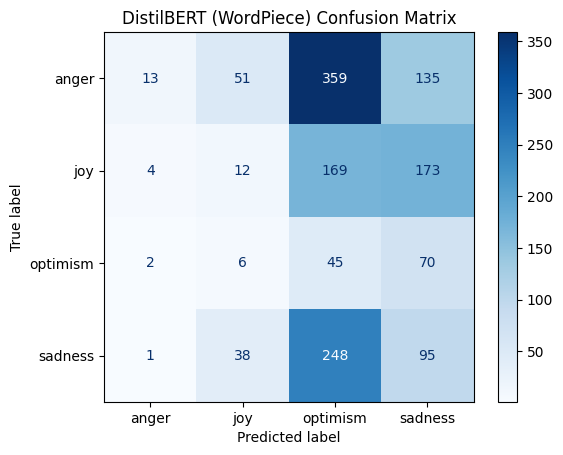

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_true = test_df['label'].map(id_labels)
y_pred_bert = test_df['distilbert_pred']
cm_bert = confusion_matrix(y_true, y_pred_bert, labels=candidate_labels)
disp_bert = ConfusionMatrixDisplay(confusion_matrix=cm_bert, display_labels=candidate_labels)
disp_bert.plot(cmap=plt.cm.Blues)
plt.title("DistilBERT (WordPiece) Confusion Matrix")
plt.show()

In [27]:
import pandas as pd
report_df = pd.DataFrame(results["DistilRoBERTa (BPE)"]["Classification Report Dict"]).transpose()
report_df

,precision,recall,f1-score,support
anger,0.478501,0.777778,0.592491,558.000000
joy,0.500000,0.002793,0.005556,358.000000
optimism,0.135965,0.504065,0.214162,123.000000
sadness,0.321429,0.047120,0.082192,382.000000
accuracy,0.362421,0.362421,0.362421,0.362421
macro avg,0.358974,0.332939,0.223600,1421.000000
weighted avg,0.412043,0.362421,0.274693,1421.000000


In [28]:
report_df.to_markdown()

'|              |   precision |    recall |   f1-score |     support |\n|:-------------|------------:|----------:|-----------:|------------:|\n| anger        |    0.478501 | 0.777778  | 0.592491   |  558        |\n| joy          |    0.5      | 0.0027933 | 0.00555556 |  358        |\n| optimism     |    0.135965 | 0.504065  | 0.214162   |  123        |\n| sadness      |    0.321429 | 0.0471204 | 0.0821918  |  382        |\n| accuracy     |    0.362421 | 0.362421  | 0.362421   |    0.362421 |\n| macro avg    |    0.358974 | 0.332939  | 0.2236     | 1421        |\n| weighted avg |    0.412043 | 0.362421  | 0.274693   | 1421        |'

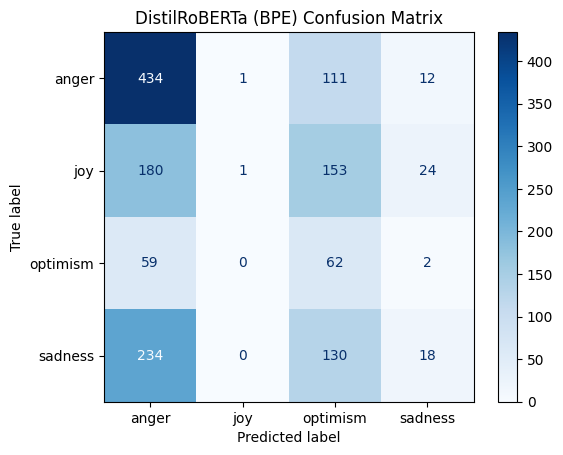

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_true = test_df['label'].map(id_labels)
y_pred_rob = test_df['distilroberta_pred']
cm_rob = confusion_matrix(y_true, y_pred_rob, labels=candidate_labels)
disp_rob = ConfusionMatrixDisplay(confusion_matrix=cm_rob, display_labels=candidate_labels)
disp_rob.plot(cmap=plt.cm.Blues)
plt.title("DistilRoBERTa (BPE) Confusion Matrix")
plt.show()

In [34]:
import pandas as pd

both_mis_df = test_df[
    (test_df['label'] != test_df['distilbert_pred'].map(labels_id)) &
    (test_df['label'] != test_df['distilroberta_pred'].map(labels_id))
].copy()

zero_shot_error_samples = both_mis_df.sample(8, random_state=15179996)

zero_shot_error_samples.to_csv("zero_shot_errors.csv", index=True)

print(f"Found {len(both_mis_df)} samples misclassified by both models in zero-shot.")
print("Displaying 8 samples with tokenization splits:\n")

for i, row in zero_shot_error_samples.iterrows():
    print(f"True Label: {id_labels[row['label']]}")
    print(f"DistilBERT pred: {row['distilbert_pred']}")
    print(f"DistilRoBERTa pred: {row['distilroberta_pred']}")
    print(f"Text: {row['text']}")

    tokens_data = show_tokenization(row['text'])
    for d in tokens_data:
        print(f"  {d['Tokenizer']} ({d['Model']}): {d['Tokens']}")
    print()

Found 772 samples misclassified by both models in zero-shot.
Displaying 8 samples with tokenization splits:

True Label: sadness
DistilBERT pred: optimism
DistilRoBERTa pred: anger
Text: #Being a #terrible #mother makes me uncomfortable.
  WordPiece (DistilBERT): ['#', 'being', 'a', '#', 'terrible', '#', 'mother', 'makes', 'me', 'uncomfortable', '.']
  BPE (DistilRoBERTa): ['#', 'Being', 'Ġa', 'Ġ#', 'ter', 'rible', 'Ġ#', 'mother', 'Ġmakes', 'Ġme', 'Ġuncomfortable', '.']

True Label: joy
DistilBERT pred: optimism
DistilRoBERTa pred: anger
Text: @user U make my heart flutter
  WordPiece (DistilBERT): ['@', 'user', 'u', 'make', 'my', 'heart', 'flutter']
  BPE (DistilRoBERTa): ['@', 'user', 'ĠU', 'Ġmake', 'Ġmy', 'Ġheart', 'Ġfl', 'utter']

True Label: joy
DistilBERT pred: sadness
DistilRoBERTa pred: anger
Text: @user @user @user People know your serious now brother! #awesome
  WordPiece (DistilBERT): ['@', 'user', '@', 'user', '@', 'user', 'people', 'know', 'your', 'serious', 'now', 'brothe

In [35]:
import pandas as pd

both_mis_df = test_df[
    (test_df['label'] != test_df['distilbert_pred'].map(labels_id)) &
    (test_df['label'] != test_df['distilroberta_pred'].map(labels_id))
].copy()

zero_shot_error_samples = both_mis_df.sample(8, random_state=15179996)

zero_shot_error_samples.to_csv("zero_shot_errors.csv", index=True)

print(f"Found {len(both_mis_df)} samples misclassified by both models in zero-shot: \n")

for i, row in zero_shot_error_samples.iterrows():
    print(f"True Label: {id_labels[row['label']]}")
    print(f"DistilBERT pred: {row['distilbert_pred']}")
    print(f"DistilRoBERTa pred: {row['distilroberta_pred']}")
    print(f"Text: {row['text']}")

    tokens_data = show_tokenization(row['text'])
    for d in tokens_data:
        print(f"  {d['Tokenizer']} ({d['Model']}): {d['Tokens']}")
    print()

Found 772 samples misclassified by both models in zero-shot: 

True Label: sadness
DistilBERT pred: optimism
DistilRoBERTa pred: anger
Text: #Being a #terrible #mother makes me uncomfortable.
  WordPiece (DistilBERT): ['#', 'being', 'a', '#', 'terrible', '#', 'mother', 'makes', 'me', 'uncomfortable', '.']
  BPE (DistilRoBERTa): ['#', 'Being', 'Ġa', 'Ġ#', 'ter', 'rible', 'Ġ#', 'mother', 'Ġmakes', 'Ġme', 'Ġuncomfortable', '.']

True Label: joy
DistilBERT pred: optimism
DistilRoBERTa pred: anger
Text: @user U make my heart flutter
  WordPiece (DistilBERT): ['@', 'user', 'u', 'make', 'my', 'heart', 'flutter']
  BPE (DistilRoBERTa): ['@', 'user', 'ĠU', 'Ġmake', 'Ġmy', 'Ġheart', 'Ġfl', 'utter']

True Label: joy
DistilBERT pred: sadness
DistilRoBERTa pred: anger
Text: @user @user @user People know your serious now brother! #awesome
  WordPiece (DistilBERT): ['@', 'user', '@', 'user', '@', 'user', 'people', 'know', 'your', 'serious', 'now', 'brother', '!', '#', 'awesome']
  BPE (DistilRoBERTa)

In [36]:
import pandas as pd
test_df['label_str'] = test_df['label'].map(id_labels)

both_wrong = test_df[(test_df['distilbert_pred'] != test_df['label_str']) & (test_df['distilroberta_pred'] != test_df['label_str'])].head(8)

bert_right_rob_wrong = test_df[(test_df['distilbert_pred'] == test_df['label_str']) & (test_df['distilroberta_pred'] != test_df['label_str'])].head(8)

rob_right_bert_wrong = test_df[(test_df['distilroberta_pred'] == test_df['label_str']) & (test_df['distilbert_pred'] != test_df['label_str'])].head(8)

print(f"Both wrong: {len(both_wrong)}")
print(f"DistilBERT right, DistilRoBERTa wrong: {len(bert_right_rob_wrong)}")
print(f"DistilRoBERTa right, DistilBERT wrong: {len(rob_right_bert_wrong)}")

both_wrong_indices = both_wrong.index.tolist()
bert_right_rob_wrong_indices = bert_right_rob_wrong.index.tolist()
rob_right_bert_wrong_indices = rob_right_bert_wrong.index.tolist()


Both wrong: 8
DistilBERT right, DistilRoBERTa wrong: 8
DistilRoBERTa right, DistilBERT wrong: 8


In [37]:
from transformers import AutoTokenizer

tokenizer_bert = DistilBERT_zero_shot_pipeline.tokenizer
tokenizer_rob = DistilRoBERTa_zero_shot_pipeline.tokenizer

def analyze_tokenization(df, title):
    for idx, row in df.iterrows():
        text = row['text']
        true_label = row['label_str']
        pred_bert = row['distilbert_pred']
        pred_rob = row['distilroberta_pred']

        tokens_bert = tokenizer_bert.tokenize(text)
        tokens_rob = tokenizer_rob.tokenize(text)

        print(f"Text: {text}")
        print(f"True: {true_label} | DistilBERT Pred: {pred_bert} | DistilRoBERTa Pred: {pred_rob}")
        print(f"WordPiece (DistilBERT): {tokens_bert}")
        print(f"BPE (DistilRoBERTa): {tokens_rob}")

analyze_tokenization(both_wrong, "Misclassified by BOTH")
analyze_tokenization(bert_right_rob_wrong, "DistilBERT Right, DistilRoBERTa Wrong")
analyze_tokenization(rob_right_bert_wrong, "DistilRoBERTa Right, DistilBERT Wrong")


Text: My visit to hospital for care triggered #trauma from accident 20+yrs ago and image of my dead brother in it. Feeling symptoms of #depression
True: sadness | DistilBERT Pred: optimism | DistilRoBERTa Pred: optimism
WordPiece (DistilBERT): ['my', 'visit', 'to', 'hospital', 'for', 'care', 'triggered', '#', 'trauma', 'from', 'accident', '20', '+', 'y', '##rs', 'ago', 'and', 'image', 'of', 'my', 'dead', 'brother', 'in', 'it', '.', 'feeling', 'symptoms', 'of', '#', 'depression']
BPE (DistilRoBERTa): ['My', 'Ġvisit', 'Ġto', 'Ġhospital', 'Ġfor', 'Ġcare', 'Ġtriggered', 'Ġ#', 'tra', 'uma', 'Ġfrom', 'Ġaccident', 'Ġ20', '+', 'yrs', 'Ġago', 'Ġand', 'Ġimage', 'Ġof', 'Ġmy', 'Ġdead', 'Ġbrother', 'Ġin', 'Ġit', '.', 'ĠFeeling', 'Ġsymptoms', 'Ġof', 'Ġ#', 'dep', 'ression']
Text: @user Welcome to #MPSVT! We are delighted to have you! #grateful #MPSVT #relationships
True: joy | DistilBERT Pred: sadness | DistilRoBERTa Pred: optimism
WordPiece (DistilBERT): ['@', 'user', 'welcome', 'to', '#', 'mps', '#

In [38]:
import json
with open("error_analysis_indices.json", "w") as f:
    json.dump({
        "both_wrong": both_wrong_indices,
        "bert_right_rob_wrong": bert_right_rob_wrong_indices,
        "rob_right_bert_wrong": rob_right_bert_wrong_indices
    }, f)
print("Saved indices to error_analysis_indices.json")


Saved indices to error_analysis_indices.json


In [39]:
import pandas as pd
from datasets import Dataset

In [40]:
id_labels = {0: "anger", 1: "joy", 2: "optimism", 3: "sadness"}
labels_id = {"anger": 0, "joy": 1, "optimism": 2, "sadness": 3}
candidate_labels = list(id_labels.values())
hypothesis_template = "This tweet expresses {}."

In [41]:
train_df, val_df, test_df = download_and_split_dataset()
print(f"Training set: {len(train_df)}")
print(f"Validation set: {len(val_df)}")
print(f"Testing set: {len(test_df)}")


Training set: 3257
Validation set: 374
Testing set: 1421


In [42]:
train_ds = Dataset.from_pandas(train_df)
val_ds = Dataset.from_pandas(val_df)
test_ds = Dataset.from_pandas(test_df)

In [43]:
ft_results = {}

# Train DistilBERT Model

In [46]:
ft_results["distilbert-base-uncased-tweeteval"] = train_and_evaluate(
    "distilbert-base-uncased",
    train_ds, val_ds, test_ds, test_df,
    "distilbert-base-uncased-tweeteval",
    candidate_labels,
    push_to_hub=False,
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/3257 [00:00<?, ? examples/s]

Map:   0%|          | 0/374 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.648250,0.614030,0.783422,0.718325
2,0.489573,0.657670,0.762032,0.700190
3,0.332053,0.647104,0.783422,0.724364
4,0.180472,0.830936,0.775401,0.714541
5,0.090310,0.943041,0.764706,0.720658
6,0.052254,1.013541,0.783422,0.726013
7,0.047376,1.170702,0.756684,0.705573
8,0.051379,1.203957,0.770053,0.723205
9,0.012876,1.385586,0.770053,0.719140


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Map:   0%|          | 0/1421 [00:00<?, ? examples/s]

Evaluating distilbert-base-uncased-tweeteval_StandardTest on provided dataset (size: 1421)...


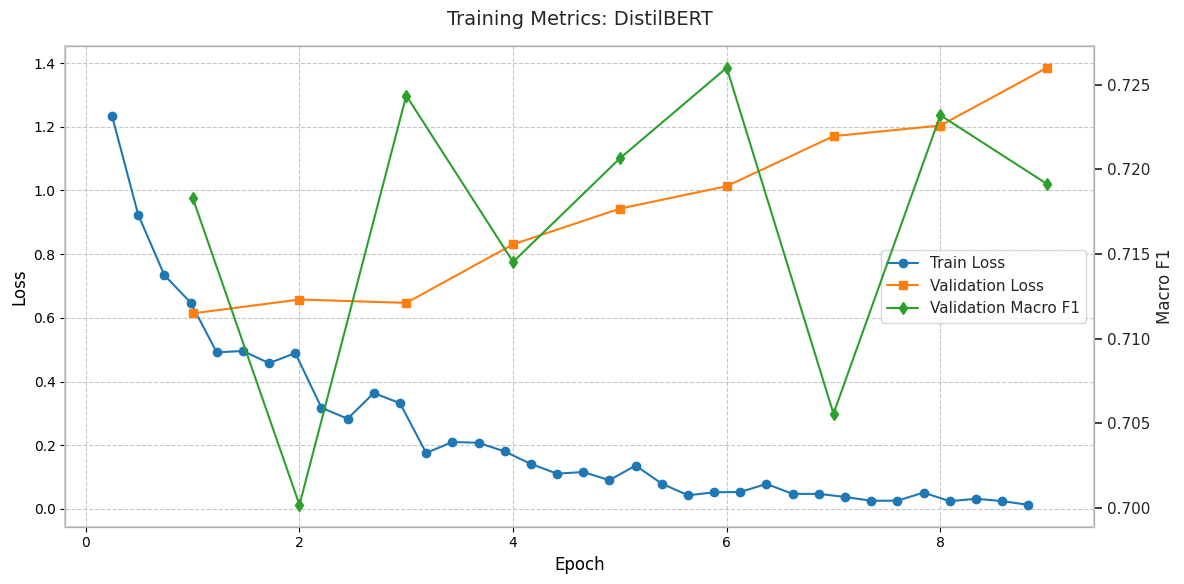

In [47]:
loss_plot(ft_results['distilbert-base-uncased-tweeteval'][0]['Log History'], 'DistilBERT')

# Train DistilRoBERTa Model

In [48]:
ft_results["distilroberta-base-tweeteval"] = train_and_evaluate(
    "distilroberta-base",
    train_ds, val_ds, test_ds, test_df,
    "distilroberta-base-tweeteval",
    candidate_labels,
)

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/3257 [00:00<?, ? examples/s]

Map:   0%|          | 0/374 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.657902,0.611988,0.786096,0.727565
2,0.540323,0.689136,0.737968,0.689912
3,0.378086,0.689269,0.783422,0.724460
4,0.271424,0.863136,0.751337,0.683844


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Map:   0%|          | 0/1421 [00:00<?, ? examples/s]

Evaluating distilroberta-base-tweeteval_StandardTest on provided dataset (size: 1421)...


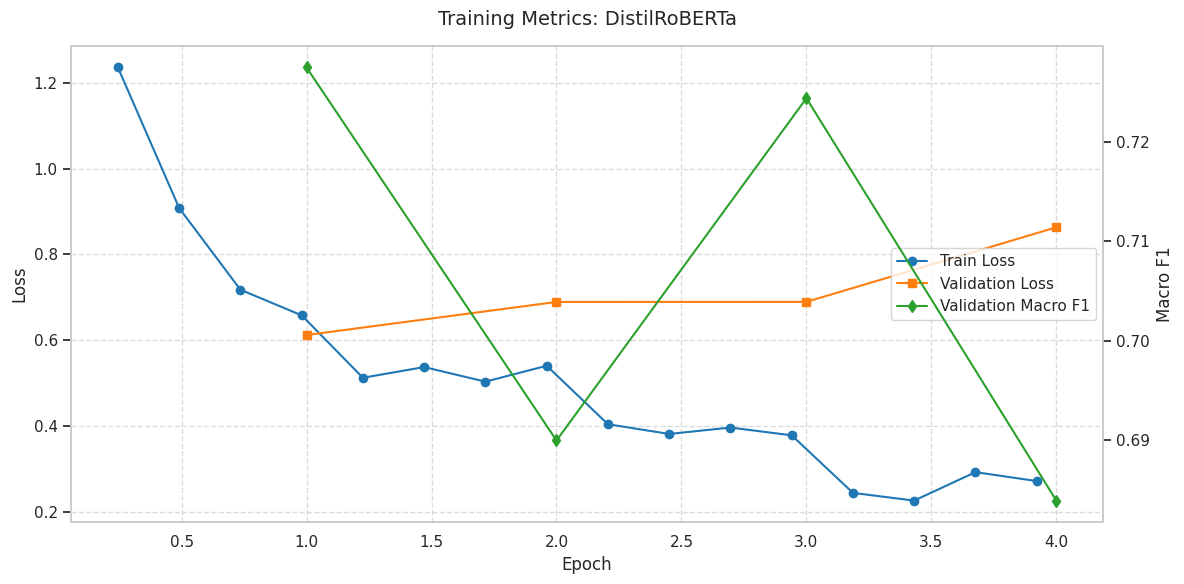

In [49]:
loss_plot(ft_results['distilroberta-base-tweeteval'][0]['Log History'], 'DistilRoBERTa')

In [50]:
final_df = pd.DataFrame({k: v[0] for k, v in ft_results.items()}).T
print(final_df[['Accuracy', 'Macro F1', 'ECE', 'Time/100']].to_string(
    formatters={'Accuracy': '{:,.2%}'.format, 'Macro F1': '{:,.2%}'.format,
                'ECE': '{:.4f}'.format, 'Time/100': '{:.2f}ms'.format}))

                                  Accuracy Macro F1     ECE  Time/100
distilbert-base-uncased-tweeteval   79.80%   76.12%  0.1698   75.39ms
distilroberta-base-tweeteval        78.89%   75.06%  0.0421  100.40ms


In [51]:
final_dict = pd.DataFrame(ft_results["distilbert-base-uncased-tweeteval"][0]["Classification Report Dict"])
final_dict

,anger,joy,optimism,sadness,accuracy,macro avg,weighted avg
precision,0.840502,0.782723,0.657407,0.790885,0.79803,0.767879,0.796758
recall,0.840502,0.835196,0.577236,0.772251,0.79803,0.756296,0.798030
f1-score,0.840502,0.808108,0.614719,0.781457,0.79803,0.761196,0.796924
support,558.000000,358.000000,123.000000,382.000000,0.79803,1421.000000,1421.000000


In [52]:
final_dict.to_markdown()

'|           |      anger |        joy |   optimism |    sadness |   accuracy |   macro avg |   weighted avg |\n|:----------|-----------:|-----------:|-----------:|-----------:|-----------:|------------:|---------------:|\n| precision |   0.840502 |   0.782723 |   0.657407 |   0.790885 |    0.79803 |    0.767879 |       0.796758 |\n| recall    |   0.840502 |   0.835196 |   0.577236 |   0.772251 |    0.79803 |    0.756296 |       0.79803  |\n| f1-score  |   0.840502 |   0.808108 |   0.614719 |   0.781457 |    0.79803 |    0.761196 |       0.796924 |\n| support   | 558        | 358        | 123        | 382        |    0.79803 | 1421        |    1421        |'

In [53]:
final_dict = pd.DataFrame(ft_results["distilroberta-base-tweeteval"][0]["Classification Report Dict"])
final_dict

,anger,joy,optimism,sadness,accuracy,macro avg,weighted avg
precision,0.787440,0.755668,0.833333,0.821752,0.788881,0.799548,0.792632
recall,0.876344,0.837989,0.487805,0.712042,0.788881,0.728545,0.788881
f1-score,0.829517,0.794702,0.615385,0.762973,0.788881,0.750644,0.784322
support,558.000000,358.000000,123.000000,382.000000,0.788881,1421.000000,1421.000000


In [54]:
final_dict.to_markdown()

'|           |      anger |        joy |   optimism |    sadness |   accuracy |   macro avg |   weighted avg |\n|:----------|-----------:|-----------:|-----------:|-----------:|-----------:|------------:|---------------:|\n| precision |   0.78744  |   0.755668 |   0.833333 |   0.821752 |   0.788881 |    0.799548 |       0.792632 |\n| recall    |   0.876344 |   0.837989 |   0.487805 |   0.712042 |   0.788881 |    0.728545 |       0.788881 |\n| f1-score  |   0.829517 |   0.794702 |   0.615385 |   0.762973 |   0.788881 |    0.750644 |       0.784322 |\n| support   | 558        | 358        | 123        | 382        |   0.788881 | 1421        |    1421        |'

Map:   0%|          | 0/1421 [00:00<?, ? examples/s]

<Figure size 600x600 with 0 Axes>

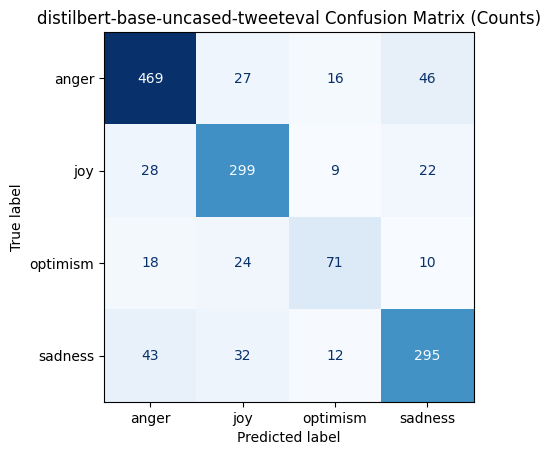

<Figure size 600x600 with 0 Axes>

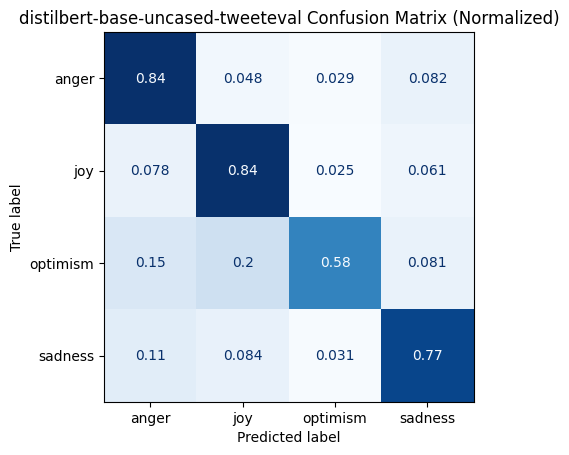

Map:   0%|          | 0/1421 [00:00<?, ? examples/s]

<Figure size 600x600 with 0 Axes>

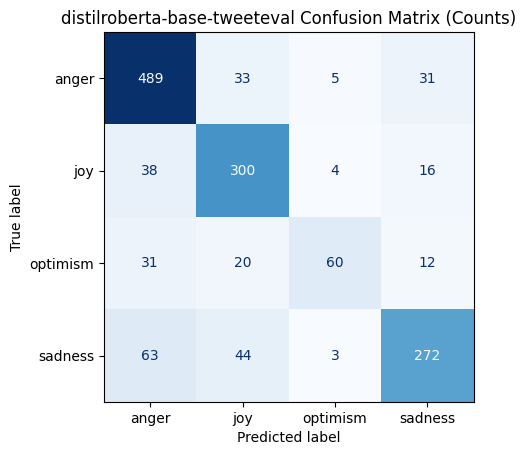

<Figure size 600x600 with 0 Axes>

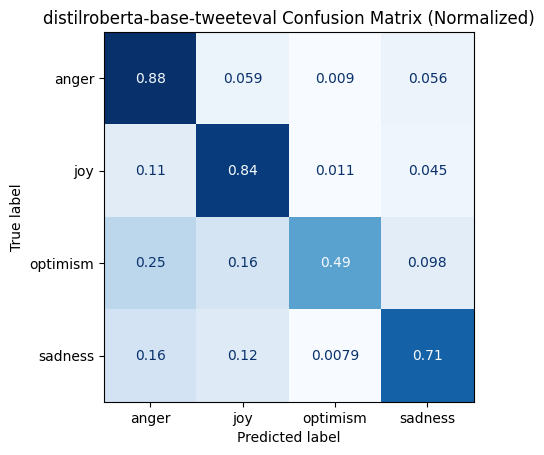

In [55]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

plt.rcdefaults()
plt.style.use("default")
plt.rcParams["axes.grid"] = False

y_true = test_df["label"]
labels_list = list(id_labels.values())

for model_key, (_, trainer, tokenizer) in ft_results.items():

    tokenized_eval = test_ds.map(
        lambda x: tokenizer(x["text"], truncation=True, padding=True),
        batched=True
    )

    preds = trainer.predict(tokenized_eval).predictions
    y_pred = np.argmax(preds, axis=-1)

    cm = confusion_matrix(y_true, y_pred)
    cm_norm = confusion_matrix(y_true, y_pred, normalize="true")

    plt.figure(figsize=(6,6))
    ConfusionMatrixDisplay(cm, display_labels=labels_list).plot(cmap="Blues", colorbar=False)
    plt.grid(False)
    plt.title(f"{model_key} Confusion Matrix (Counts)")
    plt.show()

    plt.figure(figsize=(6,6))
    ConfusionMatrixDisplay(cm_norm, display_labels=labels_list).plot(cmap="Blues", colorbar=False)
    plt.grid(False)
    plt.title(f"{model_key} Confusion Matrix (Normalized)")
    plt.show()

In [56]:
import pandas as pd
from datasets import Dataset
from transformers import Trainer, AutoModelForSequenceClassification, AutoTokenizer


In [57]:
id_labels = {0: "anger", 1: "joy", 2: "optimism", 3: "sadness"}
labels_id = {"anger": 0, "joy": 1, "optimism": 2, "sadness": 3}
candidate_labels = list(id_labels.values())
hypothesis_template = "This tweet expresses {}."

In [58]:
train_df, val_df, test_df = download_and_split_dataset()
print(f"Training set: {len(train_df)}")
print(f"Validation set: {len(val_df)}")
print(f"Testing set: {len(test_df)}")

Training set: 3257
Validation set: 374
Testing set: 1421


In [59]:
train_ds = Dataset.from_pandas(train_df)
val_ds = Dataset.from_pandas(val_df)
test_ds = Dataset.from_pandas(test_df)

In [60]:
ft_results = {}

In [61]:
import torch
import os
import sys

In [62]:
import pandas as pd
from transformers import Trainer, AutoModelForSequenceClassification, AutoTokenizer

# Run all Corruptions/Data shift

In [66]:
import os
import glob

def get_latest_checkpoint(base_path):
    checkpoints = glob.glob(os.path.join(base_path, "checkpoint-*"))
    if not checkpoints:
        return base_path
    return max(checkpoints, key=os.path.getmtime)

model_paths = {
    "distilbert": get_latest_checkpoint("/content/results_distilbert-base-uncased-tweeteval"),
    "distilroberta": get_latest_checkpoint("//content/results_distilroberta-base-tweeteval")
}

ft_results = {}

for name, model_path in model_paths.items():
    print(f"Evaluating model: {name} from {model_path}")

    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSequenceClassification.from_pretrained(model_path)

    trainer = Trainer(model=model)

    ft_results[name] = {}

    ft_results[name]["standard"] = evaluate(trainer, tokenizer, test_df, name, candidate_labels)

    print(f"\nRunning corruption ablations for {name}")
    corrupted_dfs = create_corruption_ablations(test_df)
    ft_results[name]["corruptions"] = {}
    for c_name, c_df in corrupted_dfs.items():
        ft_results[name]["corruptions"][c_name] = evaluate(trainer, tokenizer, c_df, f"{name}_{c_name}", candidate_labels)

    print(f"\nRunning domain shift ablations {name}")
    shift_dfs = create_shift_ablation_sets(test_df)
    ft_results[name]["shifts"] = {}
    for s_name, s_df in shift_dfs.items():
        ft_results[name]["shifts"][s_name] = evaluate(trainer, tokenizer, s_df, f"{name}_{s_name}", candidate_labels)

Evaluating model: distilbert from /content/results_distilbert-base-uncased-tweeteval/checkpoint-1836


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Map:   0%|          | 0/1421 [00:00<?, ? examples/s]

Evaluating distilbert on provided dataset (size: 1421)...



Running corruption ablations for distilbert


...

Evaluating distilroberta_no_links on provided dataset (size: 1421)...


Map:   0%|          | 0/673 [00:00<?, ? examples/s]

Evaluating distilroberta_with_hashtags on provided dataset (size: 673)...


Map:   0%|          | 0/748 [00:00<?, ? examples/s]

Evaluating distilroberta_no_hashtags on provided dataset (size: 748)...


In [67]:
import pandas as pd

all_rows = []

for model_path, categories in ft_results.items():
    model_name = model_path.split('/')[-1]

    for cat_type in ["corruptions", "shifts"]:
        for test_name, res in categories.get(cat_type, {}).items():
            macro_avg = res['Classification Report Dict']['macro avg']
            all_rows.append({
                'Type': cat_type.capitalize(),
                'Test': test_name,
                'Model': model_name,
                'Accuracy': res['Accuracy'],
                'Macro F1': res['Macro F1'],
                'Macro Precision': macro_avg['precision'],
                'Macro Recall': macro_avg['recall'],
                'ECE': res['ECE']
            })

df = pd.DataFrame(all_rows)

unified_df = df.pivot_table(
    index=['Type', 'Test'],
    columns='Model',
    values=['Accuracy', 'Macro F1', 'Macro Precision', 'Macro Recall', 'ECE']
)

unified_df = unified_df.swaplevel(0, 1, axis=1).sort_index(axis=1)

display(unified_df)


Model                           distilbert                      \
                                  Accuracy       ECE  Macro F1   
Type        Test                                                 
Corruptions corruption_all        0.768473  0.203342  0.729084   
            corruption_emojis     0.787474  0.188039  0.758557   
            corruption_hashtags   0.786066  0.187611  0.752547   
            corruption_typos      0.760732  0.210102  0.728838   
            original              0.786770  0.188614  0.756313   
Shifts      full_test             0.786770  0.188614  0.756313   
            no_hashtags           0.755348  0.216727  0.712904   
            no_links              0.786770  0.188614  0.756313   
            no_mentions           0.783147  0.191741  0.763861   
            with_hashtags         0.821694  0.162606  0.798858   
            with_mentions         0.791531  0.188442  0.724425   

Model                                                        distilroberta  \
                                Macro Precision Macro Recall      Accuracy   
Type        Test                                                             
Corruptions corruption_all             0.722585     0.741758      0.767065   
            corruption_emojis          0.749435     0.775763      0.779733   
            corruption_hashtags        0.747407     0.765647      0.784659   
            corruption_typos           0.727230     0.741668      0.766362   
            original                   0.749492     0.772064      0.786770   
Shifts      full_test                  0.749492     0.772064      0.786770   
            no_hashtags                0.705804     0.729056      0.772727   
            no_links                   0.749492     0.772064      0.786770   
            no_mentions                0.757517     0.781373      0.791822   
            with_hashtags              0.793576     0.813933      0.802377   
            with_mentions              0.722455     0.733080      0.780130   

Model                                                                \
                                      ECE  Macro F1 Macro Precision   
Type        Test                                                      
Corruptions corruption_all       0.147971  0.732999        0.791560   
            corruption_emojis    0.135490  0.754568        0.789826   
            corruption_hashtags  0.128326  0.757844        0.797146   
            corruption_typos     0.147652  0.732194        0.776700   
            original             0.127928  0.761680        0.797914   
Shifts      full_test            0.127928  0.761680        0.797914   
            no_hashtags          0.137869  0.731962        0.786967   
            no_links             0.127928  0.761680        0.797914   
            no_mentions          0.125360  0.775088        0.808444   
            with_hashtags        0.120381  0.787434        0.810467   
            with_mentions        0.133777  0.712801        0.779967   

Model                                         
                                Macro Recall  
Type        Test                              
Corruptions corruption_all          0.705637  
            corruption_emojis       0.734868  
            corruption_hashtags     0.735591  
            corruption_typos        0.709233  
            original                0.740930  
Shifts      full_test               0.740930  
            no_hashtags             0.703802  
            no_links                0.740930  
            no_mentions             0.756367  
            with_hashtags           0.774747  
            with_mentions           0.684286

In [68]:
unified_df.to_markdown()

"|                                        |   ('distilbert', 'Accuracy') |   ('distilbert', 'ECE') |   ('distilbert', 'Macro F1') |   ('distilbert', 'Macro Precision') |   ('distilbert', 'Macro Recall') |   ('distilroberta', 'Accuracy') |   ('distilroberta', 'ECE') |   ('distilroberta', 'Macro F1') |   ('distilroberta', 'Macro Precision') |   ('distilroberta', 'Macro Recall') |\n|:---------------------------------------|-----------------------------:|------------------------:|-----------------------------:|------------------------------------:|---------------------------------:|--------------------------------:|---------------------------:|--------------------------------:|---------------------------------------:|------------------------------------:|\n| ('Corruptions', 'corruption_all')      |                     0.768473 |                0.203342 |                     0.729084 |                            0.722585 |                         0.741758 |                        0.767065 |

In [69]:
import pandas as pd
import json
from transformers import AutoTokenizer, pipeline

In [70]:
id_labels = {0: "anger", 1: "joy", 2: "optimism", 3: "sadness"}
train_df, val_df, test_df = download_and_split_dataset()
test_df['label_str'] = test_df['label'].map(id_labels)


In [72]:
with open("/content/error_analysis_indices.json", "r") as f:
    indices = json.load(f)
    both_wrong_zero = indices['both_wrong']
    bert_right_zero = indices['bert_right_rob_wrong']
    rob_right_zero = indices['rob_right_bert_wrong']
print("Loaded zero-shot error indices.")


Loaded zero-shot error indices.


In [73]:
import os
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification

results_root = os.path.abspath("./")
local_bert_path = os.path.join(results_root, "results_distilbert-base-uncased-tweeteval")
local_rob_path = os.path.join(results_root, "results_distilroberta-base-tweeteval")

def get_model_path(base_path):
    if os.path.exists(os.path.join(base_path, "config.json")):
        return base_path
    import glob
    checkpoints = glob.glob(os.path.join(base_path, "checkpoint-*"))
    if checkpoints:
        return max(checkpoints, key=os.path.getmtime)
    return base_path

model_bert_path = get_model_path(local_bert_path)
model_rob_path = get_model_path(local_rob_path)

tokenizer_bert = AutoTokenizer.from_pretrained(model_bert_path)
tokenizer_rob = AutoTokenizer.from_pretrained(model_rob_path)

pipe_bert = pipeline("text-classification", model=model_bert_path, tokenizer=tokenizer_bert)
pipe_rob = pipeline("text-classification", model=model_rob_path, tokenizer=tokenizer_rob)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

In [74]:
def predict_batch(texts, pipe):
    preds = pipe(texts, truncation=True, max_length=512)
    return [p['label'].lower() for p in preds]

print("Generating predictions...")
texts = test_df['text'].tolist()
test_df['distilbert_pred'] = predict_batch(texts, pipe_bert)
test_df['distilroberta_pred'] = predict_batch(texts, pipe_rob)

Generating predictions...


# Error Analysis

In [75]:
def print_sample_analysis(indices, title):
    if not indices:
        return
    print(f"\n{'='*60}")
    print(f"{title}")
    print(f"{'='*60}")

    subset = test_df.loc[indices]
    for idx, row in subset.iterrows():
        text = row['text']
        true_label = row['label_str']
        pred_bert = row['distilbert_pred']
        pred_rob = row['distilroberta_pred']

        tokens_bert = tokenizer_bert.tokenize(text)
        tokens_rob = tokenizer_rob.tokenize(text)

        print(f"Text: {text}")
        print(f"True: {true_label} | Fine-Tuned DistilBERT Pred: {pred_bert} | Fine-Tuned DistilRoBERTa Pred: {pred_rob}")
        print(f"WordPiece (DistilBERT): {tokens_bert}")
        print(f"BPE (DistilRoBERTa): {tokens_rob}")
        print("-" * 50)

print_sample_analysis(both_wrong_zero, "Samples BOTH zero-shot models misclassified")
print_sample_analysis(bert_right_zero, "Samples zero-shot DistilBERT got right, but DistilRoBERTa missed")
print_sample_analysis(rob_right_zero, "Samples zero-shot DistilRoBERTa got right, but DistilBERT missed")



Samples BOTH zero-shot models misclassified
Text: My visit to hospital for care triggered #trauma from accident 20+yrs ago and image of my dead brother in it. Feeling symptoms of #depression
True: sadness | Fine-Tuned DistilBERT Pred: label_3 | Fine-Tuned DistilRoBERTa Pred: label_3
WordPiece (DistilBERT): ['my', 'visit', 'to', 'hospital', 'for', 'care', 'triggered', '#', 'trauma', 'from', 'accident', '20', '+', 'y', '##rs', 'ago', 'and', 'image', 'of', 'my', 'dead', 'brother', 'in', 'it', '.', 'feeling', 'symptoms', 'of', '#', 'depression']
BPE (DistilRoBERTa): ['My', 'Ġvisit', 'Ġto', 'Ġhospital', 'Ġfor', 'Ġcare', 'Ġtriggered', 'Ġ#', 'tra', 'uma', 'Ġfrom', 'Ġaccident', 'Ġ20', '+', 'yrs', 'Ġago', 'Ġand', 'Ġimage', 'Ġof', 'Ġmy', 'Ġdead', 'Ġbrother', 'Ġin', 'Ġit', '.', 'ĠFeeling', 'Ġsymptoms', 'Ġof', 'Ġ#', 'dep', 'ression']
--------------------------------------------------
Text: @user Welcome to #MPSVT! We are delighted to have you! #grateful #MPSVT #relationships
True: joy | Fine-Tune

In [76]:
both_wrong_ft = test_df[(test_df['distilbert_pred'] != test_df['label_str']) & (test_df['distilroberta_pred'] != test_df['label_str'])].head(8)
bert_right_rob_wrong_ft = test_df[(test_df['distilbert_pred'] == test_df['label_str']) & (test_df['distilroberta_pred'] != test_df['label_str'])].head(8)
rob_right_bert_wrong_ft = test_df[(test_df['distilroberta_pred'] == test_df['label_str']) & (test_df['distilbert_pred'] != test_df['label_str'])].head(8)

print_sample_analysis(both_wrong_ft.index.tolist(), "Misclassified by BOTH Fine-Tuned Models")
print_sample_analysis(bert_right_rob_wrong_ft.index.tolist(), "Fine-Tuned DistilBERT Right, DistilRoBERTa Wrong")
print_sample_analysis(rob_right_bert_wrong_ft.index.tolist(), "Fine-Tuned DistilRoBERTa Right, DistilBERT Wrong")



Misclassified by BOTH Fine-Tuned Models
Text: #Deppression is real. Partners w/ #depressed people truly dont understand the depth in which they affect us. Add in #anxiety &amp;makes it worse
True: sadness | Fine-Tuned DistilBERT Pred: label_3 | Fine-Tuned DistilRoBERTa Pred: label_3
WordPiece (DistilBERT): ['#', 'de', '##pp', '##ress', '##ion', 'is', 'real', '.', 'partners', 'w', '/', '#', 'depressed', 'people', 'truly', 'don', '##t', 'understand', 'the', 'depth', 'in', 'which', 'they', 'affect', 'us', '.', 'add', 'in', '#', 'anxiety', '&', 'amp', ';', 'makes', 'it', 'worse']
BPE (DistilRoBERTa): ['#', 'De', 'pp', 'ression', 'Ġis', 'Ġreal', '.', 'ĠPartners', 'Ġw', '/', 'Ġ#', 'dep', 'ressed', 'Ġpeople', 'Ġtruly', 'Ġdont', 'Ġunderstand', 'Ġthe', 'Ġdepth', 'Ġin', 'Ġwhich', 'Ġthey', 'Ġaffect', 'Ġus', '.', 'ĠAdd', 'Ġin', 'Ġ#', 'an', 'xiety', 'Ġ&', 'amp', ';', 'makes', 'Ġit', 'Ġworse']
--------------------------------------------------
Text: @user Interesting choice of words... Are you conf

# LLM Inference (Qwen, gpt 4o mini)

In [77]:
import sys
import os
import pandas as pd
import getpass
import torch

from google.colab import userdata
openai_key = userdata.get('OPENROUTER_API_KEY')

In [78]:
!pip -q install backoff

In [79]:
train_df, val_df, test_df = download_and_split_dataset()
print(f"Test set size: {len(test_df)}")

Test set size: 1421


In [80]:
evaluator_qwen = LLMEvaluator(hf_model_name="Qwen/Qwen3-4B-Instruct-2507")
evaluator_qwen.load_hf_model()

Loading HF model: Qwen/Qwen3-4B-Instruct-2507 on cuda...


config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

In [81]:
res_qwen_p1 = evaluator_qwen.evaluate(test_df, "hf", PROMPT_1_MINIMAL)


Evaluating hf (Batch size 100):   0%|          | 0/15 [00:00<?, ?it/s]The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.

Evaluating hf (Batch size 100): 100%|██████████| 15/15 [00:36<00:00,  2.45s/it]


In [82]:
res_qwen_p2 = evaluator_qwen.evaluate(test_df, "hf", PROMPT_2_STRUCTURED)


Evaluating hf (Batch size 100): 100%|██████████| 15/15 [01:12<00:00,  4.82s/it]


In [83]:
evaluator_openai = LLMEvaluator(openai_api_key=openai_key)

In [84]:
res_gpt_p1 = evaluator_openai.evaluate(test_df, "openai", PROMPT_1_MINIMAL)


Evaluating openai (Batch size 100): 100%|██████████| 15/15 [00:51<00:00,  3.45s/it]


In [85]:
res_gpt_p2 = evaluator_openai.evaluate(test_df, "openai", PROMPT_2_STRUCTURED)


Evaluating openai (Batch size 100): 100%|██████████| 15/15 [00:45<00:00,  3.06s/it]


In [86]:
results = {
    "GPT-4o-mini (Minimal)": res_gpt_p1,
    "GPT-4o-mini (Structured)": res_gpt_p2,
    "Qwen3-4B-Instruct-2507 (Minimal)": res_qwen_p1,
    "Qwen3-4B-Instruct-2507 (Structured)": res_qwen_p2
}

comparison_df = pd.DataFrame({
    k: {m: v[m] for m in ["Accuracy", "Macro-F1", "Time_per_100"]}
    for k, v in results.items()
}).transpose()

comparison_df

,Accuracy,Macro-F1,Time_per_100
GPT-4o-mini (Minimal),0.798030,0.600667,3659.577766
GPT-4o-mini (Structured),0.822660,0.781169,3391.730450
Qwen3-4B-Instruct-2507 (Minimal),0.751583,0.584864,2668.650916
Qwen3-4B-Instruct-2507 (Structured),0.812104,0.758003,5148.115888


In [87]:
comparison_df.to_markdown()

'|                                     |   Accuracy |   Macro-F1 |   Time_per_100 |\n|:------------------------------------|-----------:|-----------:|---------------:|\n| GPT-4o-mini (Minimal)               |   0.79803  |   0.600667 |        3659.58 |\n| GPT-4o-mini (Structured)            |   0.82266  |   0.781169 |        3391.73 |\n| Qwen3-4B-Instruct-2507 (Minimal)    |   0.751583 |   0.584864 |        2668.65 |\n| Qwen3-4B-Instruct-2507 (Structured) |   0.812104 |   0.758003 |        5148.12 |'

In [88]:
from datasets import Dataset

predictions_data = {
    'True_Labels': results["GPT-4o-mini (Minimal)"]["True_Labels"]
}
for k, v in results.items():
    predictions_data[k] = v["Predictions"]

predictions_dataset = Dataset.from_dict(predictions_data)

In [89]:
from sklearn.metrics import precision_score, recall_score
import pandas as pd

extended_rows = {}
for name, res in results.items():
    y_true = res['True_Labels']
    y_pred = res['Predictions']
    extended_rows[name] = {
        'Accuracy':        res['Accuracy'],
        'Macro-F1':        res['Macro-F1'],
        'Macro-Precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Macro-Recall':    recall_score(y_true, y_pred, average='macro', zero_division=0),
        'Time_per_100':    res['Time_per_100'],
    }

extended_df = pd.DataFrame(extended_rows).transpose()
print(extended_df.to_markdown())
extended_df


|                                     |   Accuracy |   Macro-F1 |   Macro-Precision |   Macro-Recall |   Time_per_100 |
|:------------------------------------|-----------:|-----------:|------------------:|---------------:|---------------:|
| GPT-4o-mini (Minimal)               |   0.79803  |   0.600667 |          0.655282 |       0.578279 |        3659.58 |
| GPT-4o-mini (Structured)            |   0.82266  |   0.781169 |          0.793068 |       0.771899 |        3391.73 |
| Qwen3-4B-Instruct-2507 (Minimal)    |   0.751583 |   0.584864 |          0.594974 |       0.581751 |        2668.65 |
| Qwen3-4B-Instruct-2507 (Structured) |   0.812104 |   0.758003 |          0.793805 |       0.741873 |        5148.12 |


,Accuracy,Macro-F1,Macro-Precision,Macro-Recall,Time_per_100
GPT-4o-mini (Minimal),0.798030,0.600667,0.655282,0.578279,3659.577766
GPT-4o-mini (Structured),0.822660,0.781169,0.793068,0.771899,3391.730450
Qwen3-4B-Instruct-2507 (Minimal),0.751583,0.584864,0.594974,0.581751,2668.650916
Qwen3-4B-Instruct-2507 (Structured),0.812104,0.758003,0.793805,0.741873,5148.115888


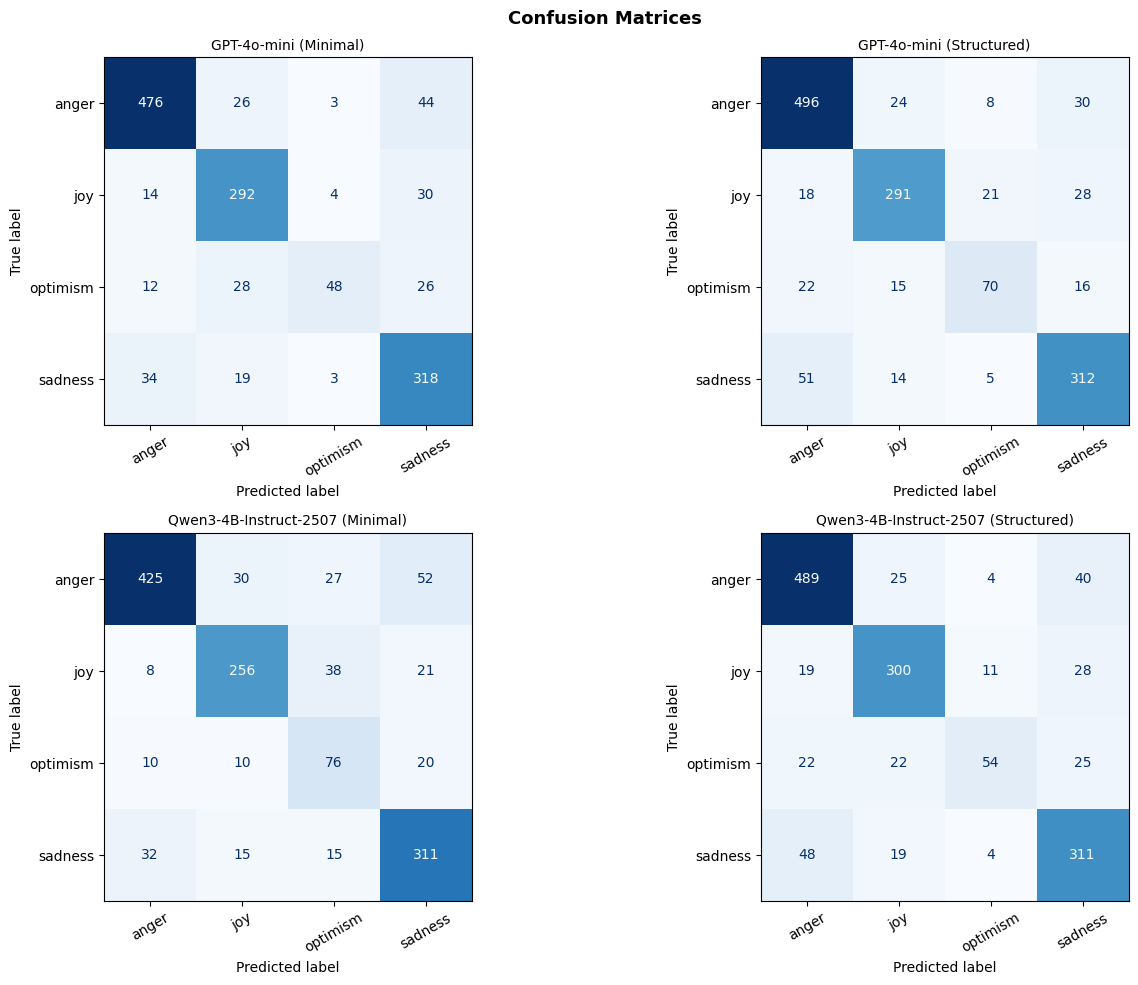

In [90]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

label_names = ['anger', 'joy', 'optimism', 'sadness']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(res['True_Labels'], res['Predictions'], labels=label_names)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=10)
    ax.tick_params(axis='x', labelrotation=30)

plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


# Question 2: n-gram modeling

In [1]:
import os
import sys
import torch
import json
import pickle
from torch.utils.data import DataLoader
from huggingface_hub import HfApi, hf_hub_download

In [2]:
import re
from datasets import load_dataset
import torch
from torch.utils.data import Dataset

# fetches jefferson text from dataset
def get_jefferson_text():
    dataset = load_dataset('khaihernlow/us-state-of-the-union-addresses-1790-2019', split='train')
    docs = []
    # filter explicitly for thomas jefferson
    for row in dataset:
        if row.get('President') == 'Thomas Jefferson':
            text_val = row.get('Text')
            docs.append(text_val)
    return " ".join(docs)

# clean and tokenize input text
def preprocess(text: str) -> list:
    # lowercase text
    text = text.lower()
    # normalize whitespace
    text = re.sub(r'\s+', ' ', text)
    # remove punctuation
    text = re.sub(r'[^\w\s\']', '', text)
    tokens = text.split()
    return tokens

def build_vocab(tokens):
    vocab = sorted(list(set(tokens)))
    # create mappings for vocabulary
    word2idx = {w: i for i, w in enumerate(vocab)}
    idx2word = {i: w for i, w in enumerate(vocab)}
    return vocab, word2idx, idx2word

class TrigramDataset(Dataset):
    def __init__(self, tokens, word2idx):
        # generate trigram pairs and targets
        self.X = []
        self.y = []
        for i in range(len(tokens) - 2):
            w1 = word2idx[tokens[i]]
            w2 = word2idx[tokens[i+1]]
            w3 = word2idx[tokens[i+2]]
            self.X.append((w1, w2))
            self.y.append(w3)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return torch.tensor(self.X[idx]), torch.tensor(self.y[idx])


In [3]:
import torch
import torch.nn.functional as F
import numpy as np

# get next word distribution
def _predict_next(model, w1, w2, word2idx):
    if hasattr(model, 'get_prob'):
        probs = []
        vocab_size = model.vocab_size
        for i in range(vocab_size):
            p = model.get_prob(w1, w2, i)
            probs.append(p)
        # normalize probabilities
        probs = torch.tensor(probs)
        return probs / torch.sum(probs)
    else:
        # neural model logic
        device = next(model.parameters()).device if list(model.parameters()) else 'cpu'
        x = torch.tensor([[w1, w2]]).to(device)
        out = model(x)
        probs = F.softmax(out, dim=-1)[0]
        return probs.cpu() # ensure return is on cpu for sampling

# greedy decoding implementation
def generate_greedy(model, w1, w2, word2idx, idx2word, num_words=80):
    words = [idx2word[w1], idx2word[w2]]
    curr_w1, curr_w2 = w1, w2
    if hasattr(model, 'eval'):
        model.eval()
    with torch.no_grad() if hasattr(model, 'eval') else torch.enable_grad():
        for _ in range(num_words):
            probs = _predict_next(model, curr_w1, curr_w2, word2idx)
            next_w = torch.argmax(probs).item()
            words.append(idx2word[next_w])
            curr_w1, curr_w2 = curr_w2, next_w
    return " ".join(words)

# beam search decoding implementation
def generate_beam_search(model, w1, w2, word2idx, idx2word, num_words=80, beam_width=3):
    curr_w1, curr_w2 = w1, w2
    beams = [(0.0, [curr_w1, curr_w2])]
    if hasattr(model, 'eval'):
        model.eval()
    with torch.no_grad() if hasattr(model, 'eval') else torch.enable_grad():
        for _ in range(num_words):
            new_beams = []
            for score, seq in beams:
                # compute log probabilities
                probs = _predict_next(model, seq[-2], seq[-1], word2idx)
                log_probs = torch.log(probs + 1e-10)
                top_log_probs, top_indices = torch.topk(log_probs, beam_width)

                for lp, idx in zip(top_log_probs, top_indices):
                    new_score = score + lp.item()
                    new_seq = seq + [idx.item()]
                    new_beams.append((new_score, new_seq))
            # sort and prune beams
            new_beams.sort(key=lambda x: x[0], reverse=True)
            beams = new_beams[:beam_width]

    best_seq = beams[0][1]
    return " ".join([idx2word[idx] for idx in best_seq])

# top k sampling implementation
def generate_top_k(model, w1, w2, word2idx, idx2word, num_words=80, k=5):
    words = [idx2word[w1], idx2word[w2]]
    curr_w1, curr_w2 = w1, w2
    if hasattr(model, 'eval'):
        model.eval()
    with torch.no_grad() if hasattr(model, 'eval') else torch.enable_grad():
        for _ in range(num_words):
            probs = _predict_next(model, curr_w1, curr_w2, word2idx)
            top_probs, top_indices = torch.topk(probs, k)
            top_probs = top_probs / torch.sum(top_probs)
            sampled_idx = torch.multinomial(top_probs, 1).item()
            next_w = top_indices[sampled_idx].item()
            words.append(idx2word[next_w])
            curr_w1, curr_w2 = curr_w2, next_w
    return " ".join(words)

# nucleus sampling implementation
def generate_nucleus(model, w1, w2, word2idx, idx2word, num_words=80, p=0.9):
    words = [idx2word[w1], idx2word[w2]]
    curr_w1, curr_w2 = w1, w2
    if hasattr(model, 'eval'):
        model.eval()
    with torch.no_grad() if hasattr(model, 'eval') else torch.enable_grad():
        for _ in range(num_words):
            probs = _predict_next(model, curr_w1, curr_w2, word2idx)
            # calculate cumulative probability
            sorted_probs, sorted_indices = torch.sort(probs, descending=True)
            cumulative_probs = torch.cumsum(sorted_probs, dim=-1)

            # filter indices above threshold
            sorted_indices_to_remove = cumulative_probs > p
            sorted_indices_to_remove[1:] = sorted_indices_to_remove[:-1].clone()
            sorted_indices_to_remove[0] = 0

            indices_to_remove = sorted_indices[sorted_indices_to_remove]
            probs[indices_to_remove] = 0
            probs = probs / torch.sum(probs)

            next_w = torch.multinomial(probs, 1).item()
            words.append(idx2word[next_w])
            curr_w1, curr_w2 = curr_w2, next_w
    return " ".join(words)

# speculative decoding implementation
def generate_speculative(target_model, draft_model, w1, w2, word2idx, idx2word, num_words=80, K=4):
    words = [idx2word[w1], idx2word[w2]]
    curr_w1, curr_w2 = w1, w2

    target_model.eval()
    device = next(target_model.parameters()).device

    # continue until length reached
    while len(words) < num_words + 2:
        draft_seq = [curr_w1, curr_w2]
        spec_tokens = []
        # generate draft tokens
        for _ in range(K):
            p_draft = _predict_next(draft_model, draft_seq[-2], draft_seq[-1], word2idx)
            next_spec = torch.argmax(p_draft).item()
            spec_tokens.append(next_spec)
            draft_seq.append(next_spec)

        spec_input = []
        for i in range(len(spec_tokens)):
             spec_input.append([draft_seq[i], draft_seq[i+1]])

        spec_input_tensor = torch.tensor(spec_input).to(device)
        with torch.no_grad():
            # get target distribution
            target_logits = target_model(spec_input_tensor)
            target_probs = torch.softmax(target_logits, dim=-1) # (K, vocab_size)

        accepted_count = 0
        # verify tokens with target
        for i in range(len(spec_tokens)):
            target_next = torch.argmax(target_probs[i]).item()
            if target_next == spec_tokens[i]:
                accepted_count += 1
            else:
                for j in range(accepted_count):
                    words.append(idx2word[spec_tokens[j]])
                words.append(idx2word[target_next])
                curr_w1, curr_w2 = draft_seq[accepted_count], target_next
                break
        else:
            for tok in spec_tokens:
                words.append(idx2word[tok])
            curr_w1, curr_w2 = draft_seq[-2], draft_seq[-1]

    return " ".join(words[:num_words+2])


In [4]:
import torch
import math
import torch.nn as nn

# compute perplexity for count model
def calculate_perplexity_count(model, test_tokens_idx):
    log_prob_sum = 0
    N = len(test_tokens_idx) - 2
    if N <= 0:
        return float('inf')

    for i in range(N):
        w1, w2, w3 = test_tokens_idx[i], test_tokens_idx[i+1], test_tokens_idx[i+2]
        prob = model.get_prob(w1, w2, w3)
        if prob == 0:
            return float('inf')
        # accumulate log probabilities
        log_prob_sum += math.log(prob)

    avg_log_prob = log_prob_sum / N
    perplexity = math.exp(-avg_log_prob)
    return perplexity

# compute perplexity for neural model
def calculate_perplexity_neural(model, test_loader, device='cpu'):
    model = model.to(device)
    model.eval()
    # use sum reduction for total loss
    criterion = nn.CrossEntropyLoss(reduction='sum').to(device)
    total_loss = 0
    total_items = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            out = model(X_batch)
            loss = criterion(out, y_batch)
            # sum loss across batches
            total_loss += loss.item()
            total_items += X_batch.size(0)

    if total_items == 0:
        return float('inf')
    avg_loss = total_loss / total_items
    perplexity = math.exp(avg_loss)
    return perplexity

# compute perplexity for text string
def get_text_perplexity(model, text, word2idx):
    # tokenize text
    tokens = text.split()
    indices = [word2idx[w] for w in tokens if w in word2idx]

    if hasattr(model, 'forward'):
        # neural model path
        from torch.utils.data import DataLoader
        device = next(model.parameters()).device if list(model.parameters()) else 'cpu'
        ds = TrigramDataset(tokens, word2idx)
        loader = DataLoader(ds, batch_size=max(1, len(ds)))
        return calculate_perplexity_neural(model, loader, device=device)
    else:
        # count model path
        return calculate_perplexity_count(model, indices)


In [5]:
import torch
import torch.nn as nn
from collections import defaultdict
import math

# count based trigram model
class CountTrigramModel:
    def __init__(self, vocab_size, add_k=1.0):
        self.vocab_size = vocab_size
        self.add_k = add_k
        self.bigram_counts = defaultdict(int)
        self.trigram_counts = defaultdict(int)

    def train(self, tokens_idx):
        # iterate tokens for counts
        for i in range(len(tokens_idx) - 2):
            w1, w2, w3 = tokens_idx[i], tokens_idx[i+1], tokens_idx[i+2]
            self.bigram_counts[(w1, w2)] += 1
            self.trigram_counts[(w1, w2, w3)] += 1

    def get_prob(self, w1, w2, w3):
        # probability with smoothing
        count_tri = self.trigram_counts.get((w1, w2, w3), 0)
        count_bi = self.bigram_counts.get((w1, w2), 0)
        return (count_tri + self.add_k) / (count_bi + self.add_k * self.vocab_size)

    def get_log_prob(self, w1, w2, w3):
        return math.log(self.get_prob(w1, w2, w3))

# neural network trigram model
class NeuralTrigramModel(nn.Module):
    def __init__(self, vocab_size, embed_size=64, hidden_size=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.fc1 = nn.Linear(embed_size * 2, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        # embed and concatenate inputs
        embeds = self.embedding(x)
        embeds = embeds.view(x.size(0), -1)
        # transform with hidden layer
        out = self.fc1(embeds)
        out = self.relu(out)
        # compute output logits
        logits = self.fc2(out)
        return logits


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim

# train neural network model
def train_neural_model(model, train_loader, val_loader, epochs=50, patience=5, lr=1e-3, device='cpu'):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_loss = float('inf')
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        # iteration over training batches
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            out = model(X_batch)
            loss = criterion(out, y_batch)
            loss.backward()
            # optimize model weights
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            # iteration over validation batches
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                out = model(X_batch)
                loss = criterion(out, y_batch)
                val_loss += loss.item()

        train_loss /= len(train_loader)
        val_loss /= len(val_loader)

        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

        # update best model state
        if val_loss < best_loss:
            best_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            patience_counter += 1
            # early stopping check
            if patience_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break

    model.load_state_dict(torch.load('best_model.pth', weights_only=True))
    model = model.to('cpu')
    return model


In [8]:
seed = 15179996
import random
random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)

# numpy seed
np.random.seed(seed)

# pytorch seeds
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

# cudnn determinism
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [9]:
text = get_jefferson_text()
tokens = preprocess(text)

# Split into train and test
split_idx = int(len(tokens) * 0.9)
train_tokens = tokens[:split_idx]
test_tokens = tokens[split_idx:]

vocab, word2idx, idx2word = build_vocab(train_tokens)
vocab_size = len(vocab)
print(f"Vocab size: {vocab_size}")
print(f"Train tokens: {len(train_tokens)}")
print(f"Test tokens: {len(test_tokens)}")

data/state_ofthe_union_texts.jsonl:   0%|          | 0.00/10.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/219 [00:00<?, ? examples/s]

Vocab size: 3005
Train tokens: 18574
Test tokens: 2064


In [10]:
train_idx = [word2idx[w] for w in train_tokens]
test_idx = [word2idx[w] for w in test_tokens if w in word2idx]

count_model = CountTrigramModel(vocab_size=vocab_size, add_k=0.1)
count_model.train(train_idx)

ppl_count = calculate_perplexity_count(count_model, test_idx)
print(f"Count Model Test Perplexity: {ppl_count:.4f}")

Count Model Test Perplexity: 1655.0892


In [11]:
train_dataset = TrigramDataset(train_tokens, word2idx)
val_split = int(len(train_dataset) * 0.9)
train_ds, val_ds = torch.utils.data.random_split(train_dataset, [val_split, len(train_dataset) - val_split])
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
nn_model = NeuralTrigramModel(vocab_size=vocab_size, embed_size=64, hidden_size=128)
nn_model = train_neural_model(nn_model, train_loader, val_loader, epochs=50, patience=5, lr=1e-3, device=device)

test_dataset = TrigramDataset([w for w in test_tokens if w in word2idx], word2idx)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)
ppl_nn = calculate_perplexity_neural(nn_model, test_loader, device=device)
print(f"Neural Model Test Perplexity: {ppl_nn:.4f}")

Epoch 1/50, Train Loss: 7.0367, Val Loss: 6.1870
Epoch 2/50, Train Loss: 5.6828, Val Loss: 5.9884
Epoch 3/50, Train Loss: 5.2788, Val Loss: 5.9405
Epoch 4/50, Train Loss: 4.9484, Val Loss: 5.9367
Epoch 5/50, Train Loss: 4.6145, Val Loss: 5.9683
Epoch 6/50, Train Loss: 4.2758, Val Loss: 6.0611
Epoch 7/50, Train Loss: 3.9279, Val Loss: 6.2084
Epoch 8/50, Train Loss: 3.5945, Val Loss: 6.4013
Epoch 9/50, Train Loss: 3.2918, Val Loss: 6.6099
Early stopping triggered at epoch 9
Neural Model Test Perplexity: 189.5496


k=0.001, Perplexity: 1237.86
k=0.010, Perplexity: 1213.06
k=0.100, Perplexity: 1655.09
k=0.500, Perplexity: 2161.24
k=1.000, Perplexity: 2385.00


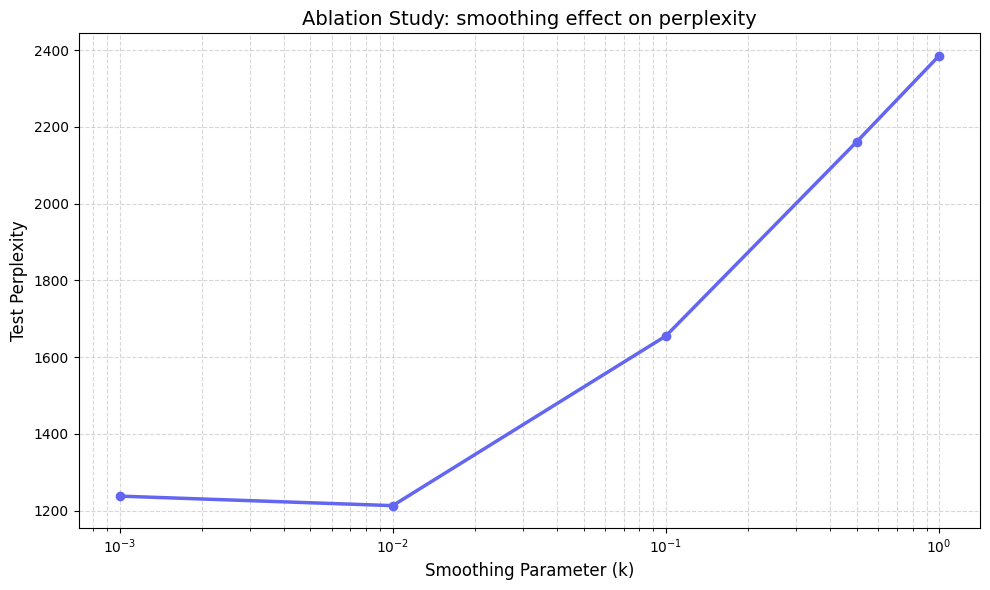

In [12]:
import numpy as np
import matplotlib.pyplot as plt

ks = [0.001, 0.01, 0.1, 0.5, 1.0]
perplexities = []

for k in ks:
    m = CountTrigramModel(vocab_size=vocab_size, add_k=k)
    m.train(train_idx)
    ppl = calculate_perplexity_count(m, test_idx)
    perplexities.append(ppl)
    print(f"k={k:.3f}, Perplexity: {ppl:.2f}")

plt.figure(figsize=(10, 6))
plt.plot(ks, perplexities, marker='o', linestyle='-', color='#6366f1', linewidth=2.5)
plt.xscale('log')
plt.xlabel('Smoothing Parameter (k)', fontsize=12)
plt.ylabel('Test Perplexity', fontsize=12)
plt.title('Ablation Study: smoothing effect on perplexity', fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [13]:
# Save Neural Model
torch.save(nn_model.state_dict(), 'nn_model.pth')

# Save Count Model (using pickle to preserve defaultdict structure)
with open('count_model.pkl', 'wb') as f:
    pickle.dump(count_model, f)

# Save Vocab
with open('vocab.json', 'w') as f:
    json.dump({'word2idx': word2idx, 'idx2word': {str(k): v for k, v in idx2word.items()}}, f)

print("Models and vocab saved locally.")

Models and vocab saved locally.


In [14]:
w1_word, w2_word = "another", "year"
w1, w2 = word2idx[w1_word], word2idx[w2_word]
seed_text = f"{w1_word} {w2_word}"

strategies = [
    ("Greedy", generate_greedy, {}),
    ("Beam Search (w=3)", generate_beam_search, {"beam_width": 3}),
    ("Top-K (K=5)", generate_top_k, {"k": 5}),
    ("Nucleus (p=0.9)", generate_nucleus, {"p": 0.9})
]

models_to_test = [
    ("Count-based Trigram Model", count_model),
    ("Neural Trigram Model", nn_model)
]

for name, model in models_to_test:
    print(f"\n{'='*20} {name} {'='*20}")
    for strat_name, func, kwargs in strategies:
        # pass local word2idx and idx2word
        generated = func(model, w1, w2, word2idx, idx2word, num_words=80, **kwargs)
        # calculate perplexity using local word2idx
        ppl = get_text_perplexity(model, generated, word2idx)
        print(f"\n[{strat_name}] (Perplexity: {ppl:.2f})")
        print(generated)



==================== Count-based Trigram Model ====================

[Greedy] (Perplexity: 173.04)
another year has been also carried on by public armed ships to the united states a great consolation that it is our duty and our harbors and jurisdiction infringements on the 30th day of september last have amounted to near 15m which have been recently made into the mediterranean fund instead thereof an equal footing with that of the united states a great consolation that it is our duty and our harbors and jurisdiction infringements on the 30th day of september last

[Beam Search (w=3)] (Perplexity: 111.27)
another year will be laid before you by the secretary of the united states a great portion of the united states a great portion of the united states a great portion of the united states a great portion of the united states a great portion of the united states a great portion of the united states a great portion of the united states a great portion of the united states a great portion 